# Figure 3 |  Global and regional rates of mangrove disturbance consisting of deforestation and degradation.

- Panel **a**: Global pattern of long-term average annual disturbance rates. The color key indicates the mean annual rate, with increasing degradation towards blue and increasing deforestation towards red, while grey represents low rates for both. 
- Panel **b**: Temporal profiles of annual rates for ten biogeographical regions. Individual points and thin lines show the annual rates of deforestation (red) and degradation (blue). The bars represent the 10-year average rate of deforestation (pink) and degradation (teal), with error bars indicating the corresponding 10-year standard deviation. Numbers within each regional panel correspond to the 10-year average rate for deforestation (red) and degradation (blue).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.transforms as transforms
import os
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

In [ ]:
def ReadingCSV(csvpath):
    df = pd.read_csv(csvpath)
    df.set_index(df.columns[0],inplace = True)
    return df

os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
df_deforestation_annualrate = pd.read_csv('Code_Data/EstimatedAnnualChange/ByGrid_AnnualDeforestationRate_XGBoost.csv')
df_degradation_annualrate = pd.read_csv('Code_Data/EstimatedAnnualChange/ByGrid_AnnualDegradationRate_XGBoost.csv')
df_deforestation_annualrate['meanlossrate'] = 100*df_deforestation_annualrate[[str(i) for i in range(1984,2023)]].apply(np.mean, axis=1)
df_degradation_annualrate['meandegrate'] = 100*df_degradation_annualrate[[str(i) for i in range(1984,2023)]].apply(np.mean, axis=1)
df_degradation_annualrate

gdf_grids = gpd.read_file('Code_Data/Grids_1degree.shp') # Read the grid shapefile
gdf_grids = gdf_grids[['ID','geometry']] # Select the columns we need
gdf_degradation = gdf_grids.merge(df_degradation_annualrate, left_on='ID', right_on='Region', how='left') # Join the degradation rate with the grid shapefile by the grid ID
gdf_degradation = gdf_degradation[gdf_degradation['ID'].isin(df_degradation_annualrate['Region'])] # Filter the grids which have degradation data

gdf_deforestation = gdf_grids.merge(df_deforestation_annualrate, left_on='ID', right_on='Region', how='left') # Join the degradation rate with the grid shapefile by the grid ID
gdf_deforestation = gdf_deforestation[gdf_deforestation['ID'].isin(df_deforestation_annualrate['Region'])] # Filter the grids which have degradation data

gdf_both = gdf_deforestation.merge(gdf_degradation[['ID','meandegrate']], left_on='ID', right_on='ID', how='left')
gdf_both['deltarate'] = gdf_both['meandegrate'] - gdf_both['meanlossrate']
gdf_both = gdf_both.replace([np.inf, -np.inf]).dropna()
# gdf_both

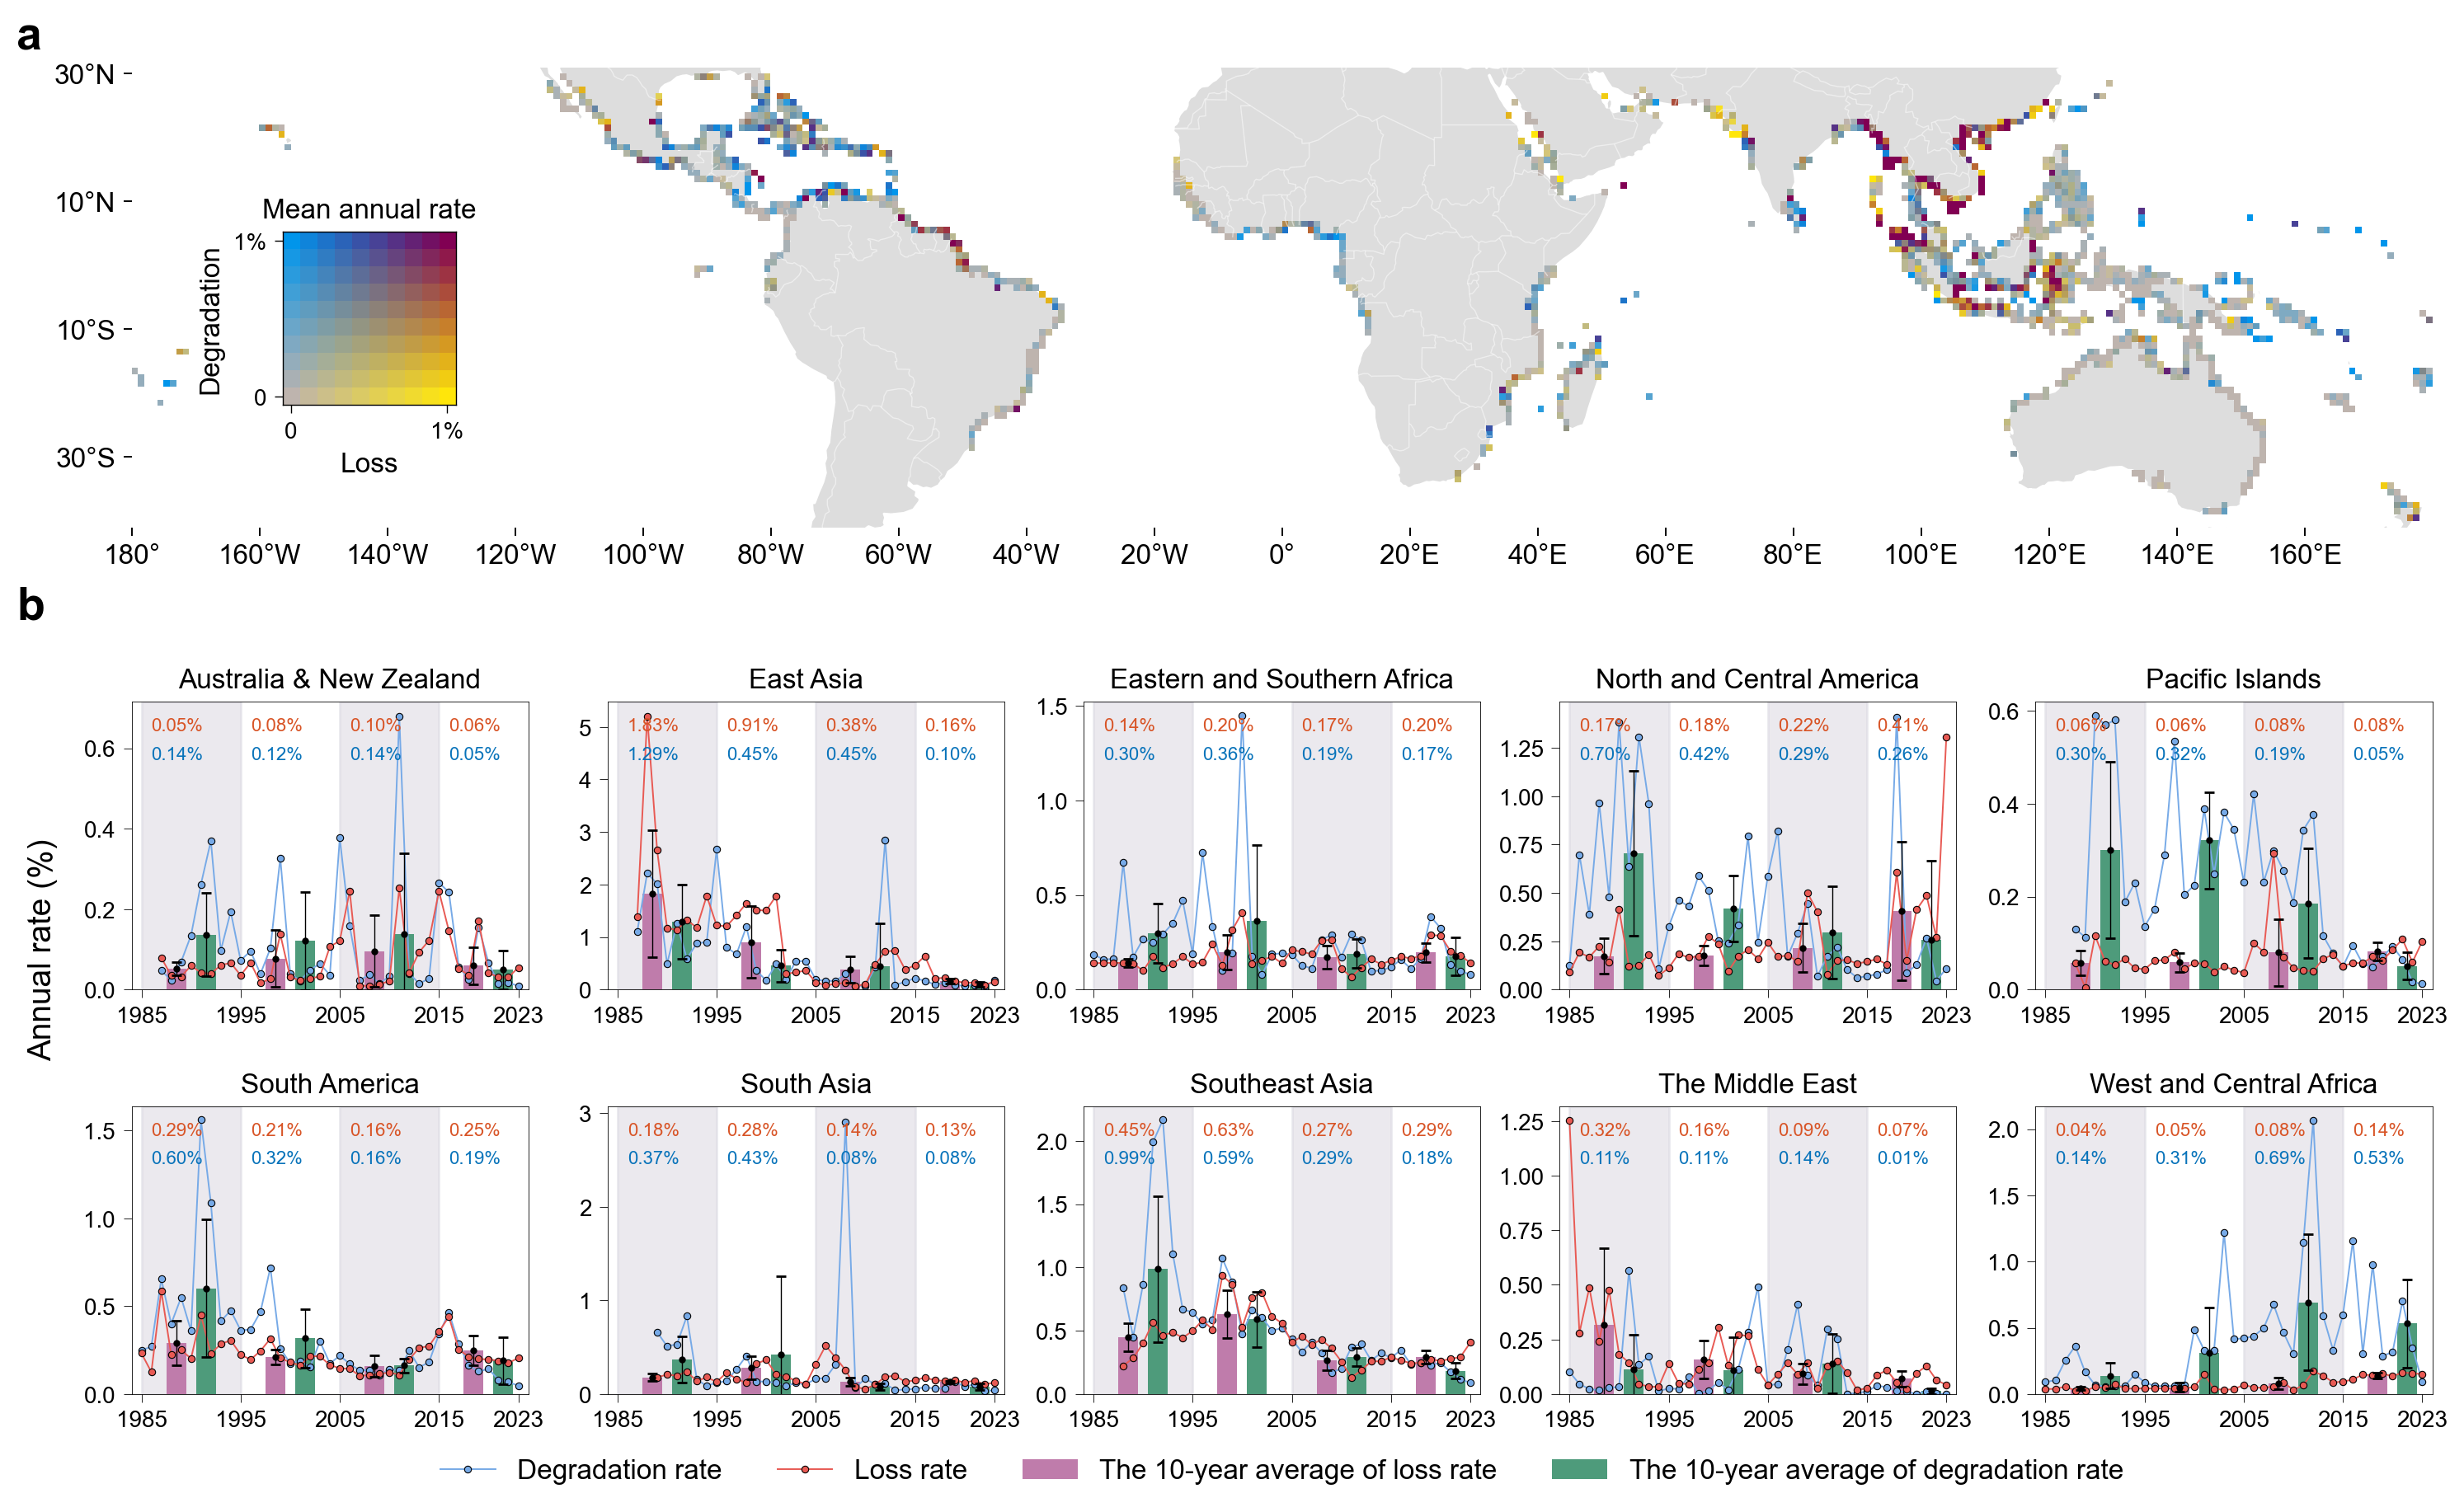

In [ ]:
fig = plt.figure(figsize=(18, 15),constrained_layout=True)
gs = GridSpec(nrows=4, ncols=5,figure=fig,height_ratios=[1,0.5,0.5,0.7],hspace=0.3,wspace=0.2)
ax1 = fig.add_subplot(gs[0,:],projection=ccrs.PlateCarree())
ZhenPlot.add_basemap(ax1,xticks=True,yticks=True,fontsize=12)
plt.text(-0.05,1.04,'a',fontdict={'size' : 20,'weight':'bold'},color='black', transform=ax1.transAxes)
gdf_both.index = range(len(gdf_both))
palette = [['#beb4ae', '#FF0000'],  ['#00fefd', 'purple']]
palette = [['#beb4ae','#ffe60b'],['#0195eb','#810053']]
cax = fig.add_axes([0.17, 0.72, 0.07, 0.07]) 


ZhenPlot.BivariatePloting('meanlossrate','meandegrate',gdf_both,ax1,palette,cb=1,cax=cax)
cax.set_xlabel('Loss',c="k", fontsize=12);cax.set_ylabel('Degradation',c="k", fontsize=12)
ax1.tick_params(axis='both', which='major', width=0.7)
ax1.set_frame_on(False)
ZhenPlot.spine_setting(cax,linewidth=0.5)

df_degradation = ReadingCSV('Code_Data/ByContinent_AnnualNewDegradation.csv')

years = list(range(1985, 2024))
bar_width = 0.42
x = np.arange(len(years))

colors = ['#ff4d4d','#5dade2']

titles = ['Australia & New Zealand','East Asia','Eastern and Southern Africa','North and Central America','Pacific Islands',
         'South America','South Asia','Southeast Asia','The Middle East','West and Central Africa']
for i,continent in enumerate(df_degradation.index.sort_values(ascending=True)):
    df_degradation = pd.read_csv(f'Code_Data/EstimatedAnnualChange/Degradation{continent}.csv')
    df_deforestation = pd.read_csv(f'Code_Data/EstimatedAnnualChange/Deforestation{continent}.csv')
    years_with_type1_area = df_degradation[df_degradation['ValidRatio'] > 0.2] # Filter the years with valid observation ratio > 10%
    first_valid_year = years_with_type1_area['Year'].tolist()[0]-1984 # Determine the first valid year
    continent_degradation = 100*df_degradation['CorrectedDegradationRate'].shift(1)[1:][first_valid_year:] # Start with the first valid year
    continent_loss = 100*df_deforestation['CorrectedDeforestationRate'].shift(1)[1:][first_valid_year:] # Start with the first valid year
    if i < 5:
        ax = fig.add_subplot(gs[1,i])
    else:
        ax = fig.add_subplot(gs[2,i-5])
    ax.plot(x[first_valid_year:], continent_degradation,label='Degradation rate',c='#77aae7',marker='.',markeredgecolor='k',markersize=6,markeredgewidth=0.4,linewidth=0.7)
    ax.plot(x[first_valid_year:], continent_loss,label='Loss rate',c='#e85a54',marker='.',markeredgecolor='k',markersize=6,markeredgewidth=0.4,linewidth=0.7)
    plt.yticks(fontsize=8)
    ax.axvspan(0, 10, alpha=0.3, color='#dad7e0',zorder=-10);ax.axvspan(20, 30, alpha=0.3, color='#dad7e0',zorder=-10)
    ax.set_xlim(-1,39)

    lossrates,drates = [],[]
    lossrates_std,drates_std = [],[]
    for start in [0,10,20,30]:
        lossrate = np.nanmean(continent_loss[start:start+10])
        drate = np.nanmean(continent_degradation[start:start+10])
        lossrate_std = np.nanstd(continent_loss[start:start+10])
        drate_std = np.nanstd(continent_degradation[start:start+10])
        trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
        ax.text(start+1,0.9,f'{lossrate:.2f}%',fontsize=8,color='#d85426', transform=trans)
        ax.text(start+1,0.8,f'{drate:.2f}%',fontsize=8,color='#0873ba', transform=trans)
        lossrates.append(lossrate);drates.append(drate)
        lossrates_std.append(lossrate_std);drates_std.append(drate_std)

    ax.bar([3.5,13.5,23.5,33.5],lossrates,2,color='#bf7cab', label='The 10-year average of loss rate',edgecolor='none')
    ax.bar([6.5,16.5,26.5,36.5],drates,2,color='#4e9b7b', label='The 10-year average of degradation rate',edgecolor='none')
    ax.errorbar([3.5,13.5,23.5,33.5],lossrates,lossrates_std,fmt='o', color='black', 
        ecolor='black', elinewidth=0.5, capsize=2, markersize=2)
    ax.errorbar([6.5,16.5,26.5,36.5],drates,drates_std,fmt='o', color='black', 
        ecolor='black', elinewidth=0.5, capsize=2, markersize=2)

    ax.set_title(titles[i])
    ax.set_xticks([0,10,20,30,38], labels=[1985,1995,2005,2015,2023])
    ax.axvspan(0, 10, alpha=0.3, color='#dad7e0',zorder=-10);ax.axvspan(20, 30, alpha=0.3, color='#dad7e0',zorder=-10)
    ax.set_xlim(-1,39)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax)
    ax.tick_params(axis='both', which='major', width=0.7, labelsize=10)
    ZhenPlot.spine_setting(ax,linewidth=0.3)

plt.legend(loc='lower center',ncol=4, fontsize=12, bbox_to_anchor=(-1.9, -0.4), frameon=False)
fig.supylabel('Annual rate (%)',x=0.09, fontsize=14)
plt.text(-0.05,-0.2,'b',fontdict={'size' : 20,'weight':'bold'},color='black', transform=ax1.transAxes)


plt.savefig("Figures/Figure3.png", dpi=500, format='png', bbox_inches='tight')
plt.savefig("Figures/Figure3.pdf", dpi=500, format='pdf', bbox_inches='tight')